# 02 — Topic Modelling (LDA + BERTopic)
**Input:** `DATA_cleaned.xlsx` → **Output:** `topic_modelling_output.xlsx`

**Goal:** Cluster complaints into interpretable topics, auto-label each topic, and measure which topics are most associated with Important Events.

- LDA: coherence sweep (k=6→24), train best model, assign dominant topic to each row
- BERTopic: rich embeddings, low noise ratio, auto-label from top bigrams
- Both: Important Event rate per topic = which complaint clusters are dangerous

In [1]:
# Run once:
# !pip install gensim bertopic sentence-transformers umap-learn hdbscan openpyxl spacy matplotlib seaborn
# !python -m spacy download en_core_web_sm
import pandas as pd, numpy as np, re, warnings
warnings.filterwarnings('ignore')
import gensim.corpora as corpora
from gensim.models import LdaModel, CoherenceModel
from bertopic import BERTopic
from bertopic.representation import KeyBERTInspired
from sentence_transformers import SentenceTransformer
from umap import UMAP
from hdbscan import HDBSCAN
from sklearn.feature_extraction.text import CountVectorizer
from collections import Counter
import spacy
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
nlp = spacy.load('en_core_web_sm', disable=['parser','ner'])
print('Imports OK.')

Imports OK.


In [2]:
# FIX: Now reads from DATA_cleaned_v2.xlsx (better cleaned input)
# This gives LDA/BERTopic cleaner vocabulary — no 'Cutomer','failue','uLL' noise
INPUT_PATH  = 'DATA_cleaned_v2.xlsx'
OUTPUT_PATH = 'topic_modelling_v2_output.xlsx'

df = pd.read_excel(INPUT_PATH)
print(f'Loaded {len(df):,} rows, {df.shape[1]} cols')

lda_texts  = df['desc1_clean_lda'].fillna('').astype(str).tolist()
bert_texts = df['desc1_clean_bert'].fillna('').astype(str).tolist()

# Build richer BERTopic input using v2 cleaned notes
# v2 cleaning fixed: 8365 Cutomer→Customer, 5372 uLL→error, 1309 failue→failure
# This means embeddings now cluster on actual fault semantics, not noise tokens
import re

ARTIFACT_PATTERNS = re.compile(
    r'(by engineer|cutomer|eupected|resuts|resoluion|faction|'
    r'ueupected|touhscreen|\[id\]|redacted|\bue\b|\bfaut\b)',
    re.IGNORECASE
)

def build_clean_bert_input(row):
    d = str(row.get('desc1_clean_bert', '')).strip()
    if d == 'nan': d = ''
    p = str(row.get('notes_problem_desc', '')).strip()
    if p and p != 'nan' and len(p) > 15:
        hits  = len(ARTIFACT_PATTERNS.findall(p))
        ratio = hits / max(len(p.split()), 1)
        if ratio < 0.15:
            d = d + ' ' + p[:300]
    return d.strip() if d.strip() else 'no description'

bert_rich_texts = df.apply(build_clean_bert_input, axis=1).tolist()

lda_valid_idx  = [i for i, t in enumerate(lda_texts)       if len(t.split()) >= 2]
bert_valid_idx = [i for i, t in enumerate(bert_rich_texts) if len(t.split()) >= 2]
lda_corpus     = [lda_texts[i]       for i in lda_valid_idx]
bert_corpus    = [bert_rich_texts[i] for i in bert_valid_idx]
print(f'LDA usable rows:     {len(lda_corpus)}')
print(f'BERTopic usable rows:{len(bert_corpus)}')


Loaded 3,999 rows, 82 cols
LDA usable rows:     3483
BERTopic usable rows:3992


## Part A — LDA

In [3]:
tokenized = [t.split() for t in lda_corpus]
id2word   = corpora.Dictionary(tokenized)
id2word.filter_extremes(no_below=3, no_above=0.6)
corpus_bow = [id2word.doc2bow(t) for t in tokenized]
print(f'Vocabulary: {len(id2word)} | Documents: {len(corpus_bow)}')

Vocabulary: 703 | Documents: 3483


Coherence sweep:
  k= 6  coherence=0.4693
  k= 8  coherence=0.4210
  k=10  coherence=0.4528
  k=12  coherence=0.4726
  k=14  coherence=0.4838
  k=16  coherence=0.5107
  k=18  coherence=0.5147

Best k = 18  (coherence = 0.5147)


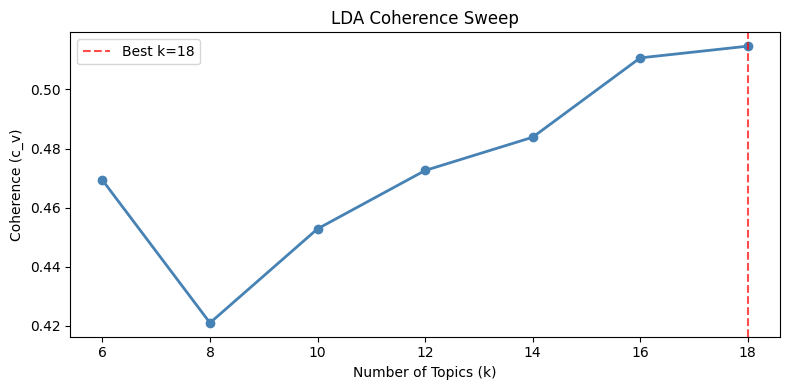

Saved: lda_coherence_sweep.png


In [4]:
# Coherence sweep — finds optimal k
# ~6-10 min. Extend K_VALUES if scores keep rising.
K_VALUES = [6, 8, 10, 12, 14, 16, 18]
coherence_scores = []
print('Coherence sweep:')
for k in K_VALUES:
    m = LdaModel(corpus=corpus_bow, id2word=id2word, num_topics=k,
                 random_state=42, passes=10, alpha='auto', eta='auto')
    score = CoherenceModel(model=m, texts=tokenized, dictionary=id2word,
                           coherence='c_v').get_coherence()
    coherence_scores.append(score)
    print(f'  k={k:2d}  coherence={score:.4f}')

best_k = K_VALUES[np.argmax(coherence_scores)]
print(f'\nBest k = {best_k}  (coherence = {max(coherence_scores):.4f})')

plt.figure(figsize=(8,4))
plt.plot(K_VALUES, coherence_scores, 'o-', color='steelblue', lw=2)
plt.axvline(best_k, linestyle='--', color='red', alpha=0.7, label=f'Best k={best_k}')
plt.xlabel('Number of Topics (k)'); plt.ylabel('Coherence (c_v)')
plt.title('LDA Coherence Sweep'); plt.legend(); plt.tight_layout()
plt.savefig('lda_coherence_sweep.png', dpi=150); plt.show()
print('Saved: lda_coherence_sweep.png')

In [5]:
# Override if sweep doesn't give a clear elbow
# BEST_K = 12
BEST_K = best_k

lda_model = LdaModel(corpus=corpus_bow, id2word=id2word, num_topics=BEST_K,
                     random_state=42, passes=20, alpha='auto', eta='auto',
                     per_word_topics=True)

print(f'Trained LDA k={BEST_K}. Top words per topic:')
for i, topic in lda_model.print_topics(num_words=10):
    print(f'  Topic {i:2d}: {topic}')

Trained LDA k=18. Top words per topic:
  Topic  0: 0.136*"charge" + 0.081*"battery" + 0.059*"machine" + 0.054*"switch" + 0.049*"break" + 0.048*"cable" + 0.037*"replacement" + 0.036*"arm" + 0.033*"space" + 0.027*"low"
  Topic  1: 0.104*"comer" + 0.090*"defective" + 0.063*"lead" + 0.044*"quote" + 0.040*"replace" + 0.037*"station" + 0.036*"automatically" + 0.025*"range" + 0.021*"trace" + 0.021*"life"
  Topic  2: 0.096*"failure" + 0.096*"ray" + 0.080*"image" + 0.077*"possible" + 0.053*"low" + 0.051*"error" + 0.036*"leak" + 0.035*"exposure" + 0.033*"tube" + 0.031*"disk"
  Topic  3: 0.207*"battery" + 0.165*"monitor" + 0.079*"defibrillator" + 0.042*"failure" + 0.038*"volume" + 0.032*"tidal" + 0.027*"low" + 0.025*"live" + 0.022*"replace" + 0.021*"examination"
  Topic  4: 0.156*"sound" + 0.142*"audio" + 0.133*"speaker" + 0.084*"find" + 0.071*"replace" + 0.045*"bench" + 0.027*"trouble" + 0.025*"fault" + 0.024*"foul" + 0.024*"malfunction"
  Topic  5: 0.103*"speaker" + 0.088*"malfunction" + 0.086*

In [7]:
# ── Improved LDA auto-labeller ────────────────────────────────────────────
GENERIC_LABEL_WORDS = {
    'system','fail','failure','unable','come','comer','possible','available',
    'occur','make','find','require','information','unknown','general','new',
    'old','good','need','want','seem','look','use','used','get','give',
    'pende','dam','gee','pro','rue',
    'repair','bench','replace','time','pass','remove',
}

DOMAIN_MAP = {
    'aed':'AED', 'defibrillator':'Defibrillator', 'ventilator':'Ventilator',
    'monitor':'Patient Monitor', 'fleuvision':'Fleuvision',
    'fluoroscopy':'Fluoroscopy', 'fluoro':'Fluoroscopy',
    'speaker':'Audio Speaker', 'touchscreen':'Touchscreen',
    'footswitch':'Footswitch', 'battery':'Battery', 'screen':'Screen',
    'display':'Display', 'cable':'Cable', 'paddle':'Paddle',
    'sensor':'Sensor', 'generator':'X-ray Generator', 'ray':'X-ray',
    'blower':'Blower Fan', 'pressure':'Pressure', 'tube':'X-ray Tube',
    'chirp':'Triple Chirp', 'boot':'Boot Failure', 'startup':'Startup Failure',
    'alarm':'Alarm Failure', 'charge':'Charging Issue', 'sound':'No Sound',
    'audio':'Audio Failure', 'tidal':'Tidal Volume', 'volume':'Volume Issue',
    'selftest':'Self-Test Fail', 'self':'Self-Test', 'test':'Test Failure',
    'therapy':'Therapy Delivery', 'exposure':'Exposure Issue',
    'geometry':'Geometry Error', 'movement':'Movement Issue',
    'image':'Imaging Failure', 'disk':'Disk Full', 'wireless':'Wireless',
    'switch':'Switch', 'power':'Power Issue', 'leak':'Leak',
    'circuit':'Circuit Failure', 'hardware':'Hardware Failure',
    'proximal':'Proximal Pressure', 'reinsert':'Battery Reinsert',
    'intermittent':'Intermittent Fault', 'backup':'Backup Alarm',
    'primary':'Primary Alarm', 'split':'Split Screen', 'black':'Black Screen',
    'damage':'Physical Damage', 'connector':'Connector Issue',
    'foot':'Footswitch', 'log':'Error Log', 'arm':'Imaging Arm',
    'plate':'Imaging Plate', 'defibrillation':'Defibrillation',
    'pacing':'Pacing Failure',
}

def improved_lda_label(lda_model, topic_id, top_n=10):
    word_scores = lda_model.show_topic(topic_id, topn=top_n)
    mapped = []
    seen   = set()
    for word, score in word_scores:
        w = word.lower().strip()
        if w in GENERIC_LABEL_WORDS: continue
        if len(w) <= 2: continue
        mapped_word = DOMAIN_MAP.get(w, word.title())
        if mapped_word not in seen:
            mapped.append((mapped_word, score))
            seen.add(mapped_word)
        if len(mapped) >= 3: break
    if not mapped:
        return ' / '.join([w.title() for w, _ in word_scores[:2]])
    return ' — '.join([m[0] for m in mapped[:2]]) if len(mapped) >= 2 else mapped[0][0]

LDA_TOPIC_LABELS = {i: improved_lda_label(lda_model, i) for i in range(BEST_K)}

# FIX: Don't recompute dominant_topic here — just print labels and raw words
print('Improved LDA topic labels:')
for k, v in LDA_TOPIC_LABELS.items():
    top_words = ', '.join([w for w, _ in lda_model.show_topic(k, topn=6)])
    print(f'  Topic {k:2d} → "{v}"')
    print(f'           raw words: {top_words}')

Improved LDA topic labels:
  Topic  0 → "Charging Issue — Battery"
           raw words: charge, battery, machine, switch, break, cable
  Topic  1 → "Defective — Lead"
           raw words: comer, defective, lead, quote, replace, station
  Topic  2 → "X-ray — Imaging Failure"
           raw words: failure, ray, image, possible, low, error
  Topic  3 → "Battery — Patient Monitor"
           raw words: battery, monitor, defibrillator, failure, volume, tidal
  Topic  4 → "No Sound — Audio Failure"
           raw words: sound, audio, speaker, find, replace, bench
  Topic  5 → "Audio Speaker — Malfunction"
           raw words: speaker, malfunction, replace, card, assembly, pcb
  Topic  6 → "Physical Damage — Fall"
           raw words: repair, pende, damage, bench, fall, port
  Topic  7 → "Triple Chirp — Triple"
           raw words: chirp, triple, emit, touch, remove, beep
  Topic  8 → "Power Issue — Pressure"
           raw words: power, pressure, fail, wireless, foot, sensor
  Topic  9 

### ✏️ Optional: Override auto-labels after reading the output above
```python
# Example:
LDA_TOPIC_LABELS[0] = 'Battery / Power Issues'
LDA_TOPIC_LABELS[1] = 'Alarm / Audio Failure'
# etc.
```

In [8]:
# ── Assign dominant topic to every row ───────────────────────────────────
def dominant_topic(bow):
    probs = lda_model.get_document_topics(bow, minimum_probability=0)
    top   = max(probs, key=lambda x: x[1])
    return top[0], round(top[1], 4)

results = [dominant_topic(bow) for bow in corpus_bow]
df['lda_topic_id']    = pd.Series([r[0] for r in results], index=lda_valid_idx)
df['lda_topic_prob']  = pd.Series([r[1] for r in results], index=lda_valid_idx)
df['lda_topic_label'] = df['lda_topic_id'].map(LDA_TOPIC_LABELS)

# Full probability distribution per doc (useful as classification features)
topic_matrix = np.zeros((len(corpus_bow), BEST_K))
for idx, bow in enumerate(corpus_bow):
    for tid, prob in lda_model.get_document_topics(bow, minimum_probability=0):
        topic_matrix[idx, tid] = prob
topic_prob_df = pd.DataFrame(topic_matrix, index=lda_valid_idx,
                             columns=[f'lda_prob_t{i}' for i in range(BEST_K)])
df = df.join(topic_prob_df, how='left')
print('LDA distribution:')
print(df['lda_topic_label'].value_counts())

LDA distribution:
lda_topic_label
Alarm Failure — Start              418
Test Failure — Boot Failure        415
Power Issue — Pressure             359
Battery — Patient Monitor          274
X-ray — Imaging Failure            271
Split Screen — Patient             200
Charging Issue — Battery           193
Triple Chirp — Triple              176
Product — Import                   166
No Sound — Audio Failure           163
Screen — Button                    145
Ullmessage — Room                  143
Movement Issue — Geometry Error    118
Audio Speaker — Malfunction        109
Complete — Stop                    107
Physical Damage — Fall              95
Provide — Faulty                    72
Defective — Lead                    59
Name: count, dtype: int64


In [9]:
# ── LDA: Important Event rate per topic ──────────────────────────────────
lda_event_rate = df[df['Important Event'].isin(['Yes','No'])].groupby('lda_topic_label').apply(
    lambda g: pd.Series({
        'n_records': len(g),
        'n_important': (g['Important Event'] == 'Yes').sum(),
        'event_rate_%': round((g['Important Event'] == 'Yes').mean() * 100, 1)
    })
).sort_values('event_rate_%', ascending=False).reset_index()

print('LDA — Important Event Rate per Topic:')
print(lda_event_rate.to_string(index=False))

LDA — Important Event Rate per Topic:
                lda_topic_label  n_records  n_important  event_rate_%
         Split Screen — Patient      198.0         30.0          15.2
               Provide — Faulty       72.0          6.0           8.3
              Ullmessage — Room      143.0         11.0           7.7
               Defective — Lead       58.0          4.0           6.9
      Battery — Patient Monitor      267.0         14.0           5.2
          Alarm Failure — Start      416.0         21.0           5.0
                Complete — Stop      107.0          4.0           3.7
               Product — Import      165.0          6.0           3.6
         Physical Damage — Fall       95.0          3.0           3.2
       No Sound — Audio Failure      163.0          4.0           2.5
                Screen — Button      145.0          3.0           2.1
        X-ray — Imaging Failure      271.0          5.0           1.8
          Triple Chirp — Triple      176.0          

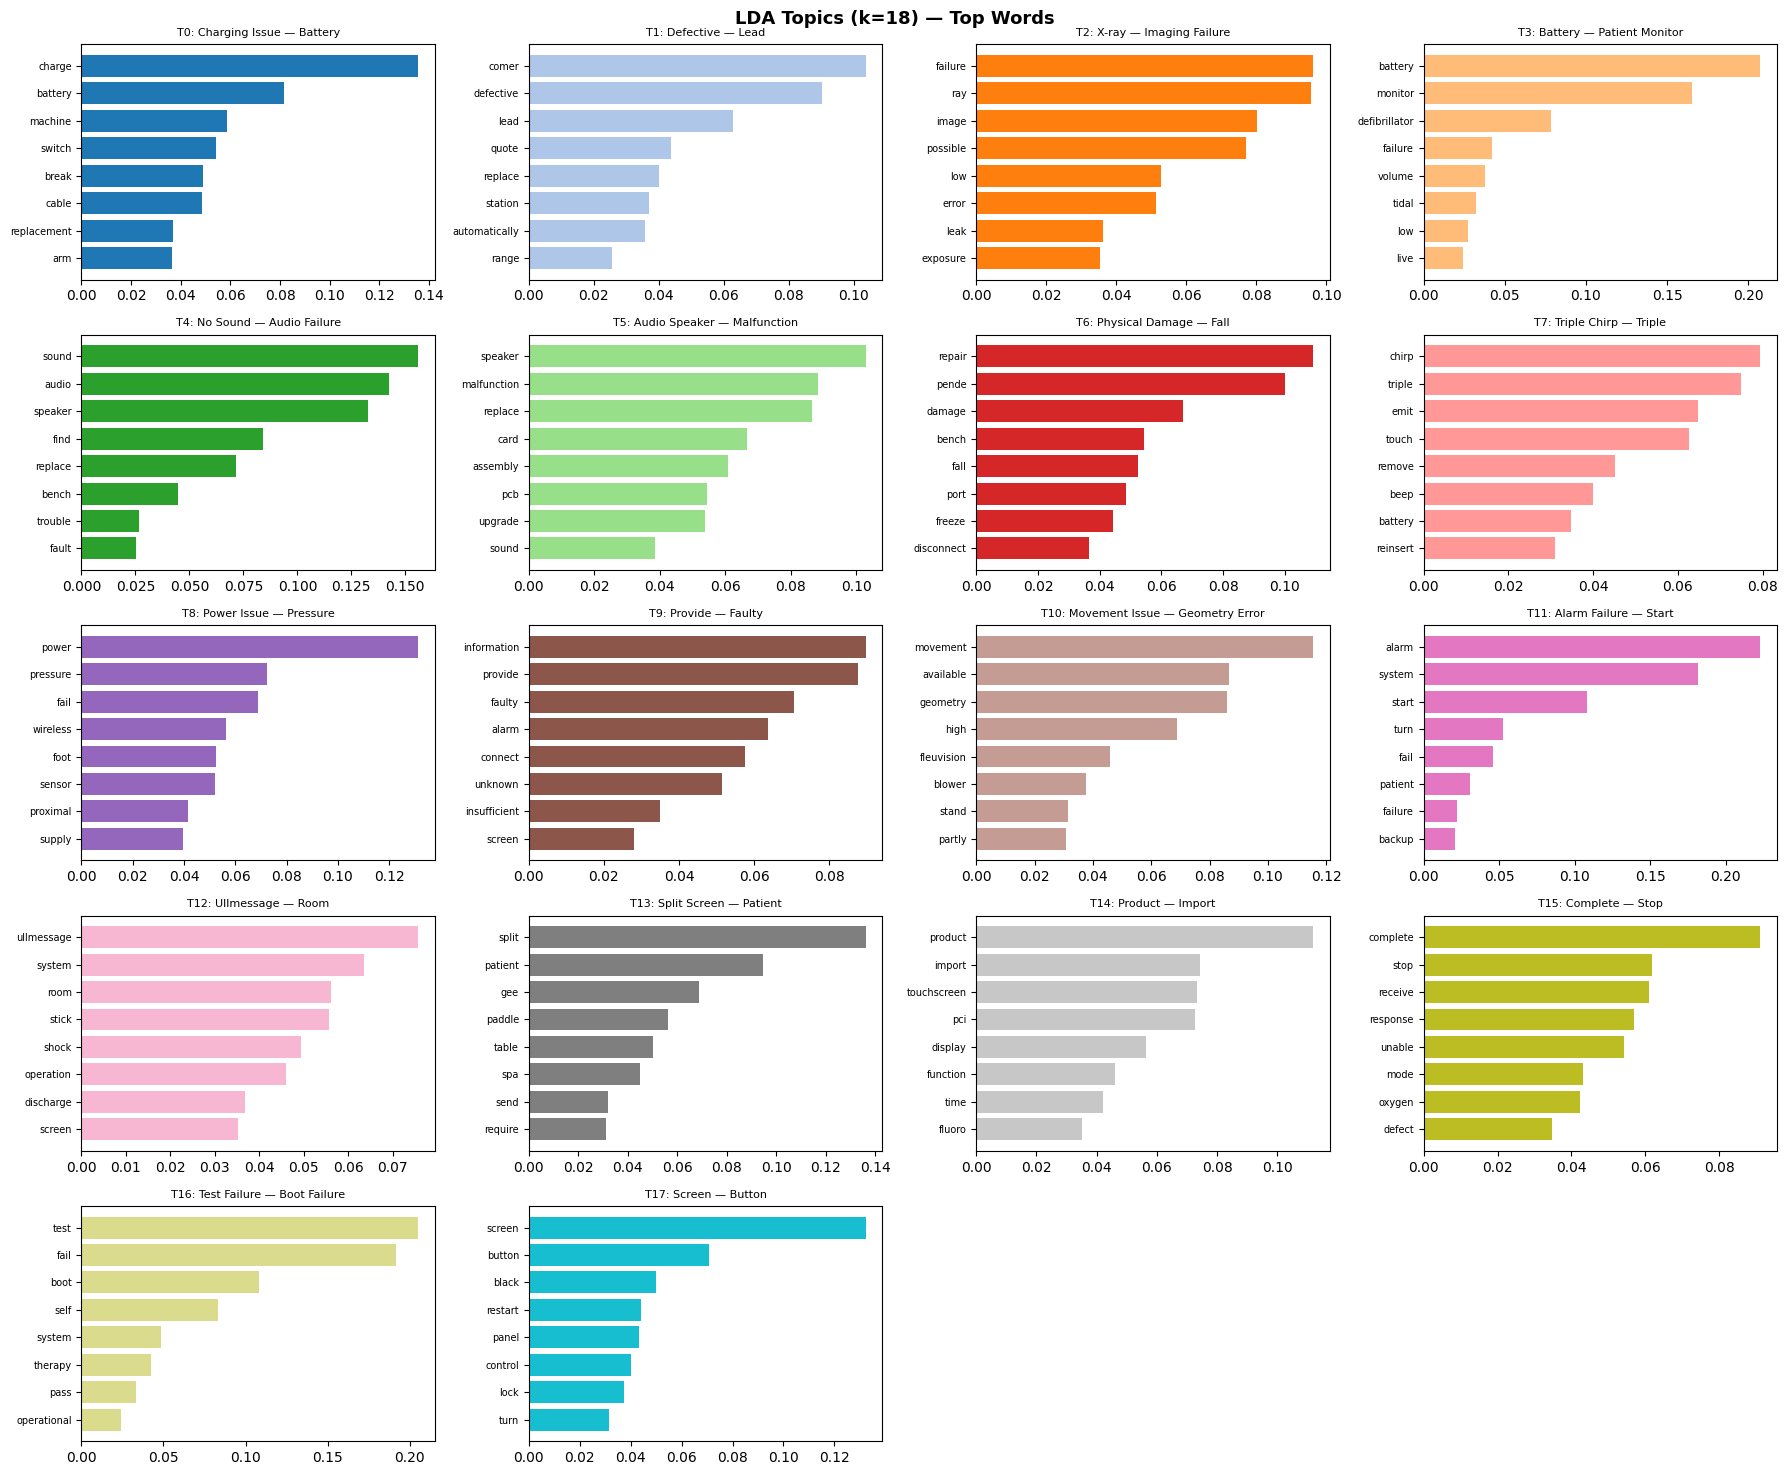

Saved: lda_topics_words.png


In [10]:
# ── LDA plots ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots((BEST_K+3)//4, 4, figsize=(18, ((BEST_K+3)//4)*3))
axes = axes.flatten()
for i in range(BEST_K):
    words_scores = lda_model.show_topic(i, topn=8)
    words  = [w[0] for w in words_scores]
    scores = [w[1] for w in words_scores]
    axes[i].barh(words[::-1], scores[::-1], color=cm.tab20(i/BEST_K))
    axes[i].set_title(f'T{i}: {LDA_TOPIC_LABELS.get(i,"")}', fontsize=8)
    axes[i].tick_params(axis='y', labelsize=7)
for ax in axes[BEST_K:]: ax.set_visible(False)
plt.suptitle(f'LDA Topics (k={BEST_K}) — Top Words', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.savefig('lda_topics_words.png', dpi=150, bbox_inches='tight')
plt.show(); print('Saved: lda_topics_words.png')

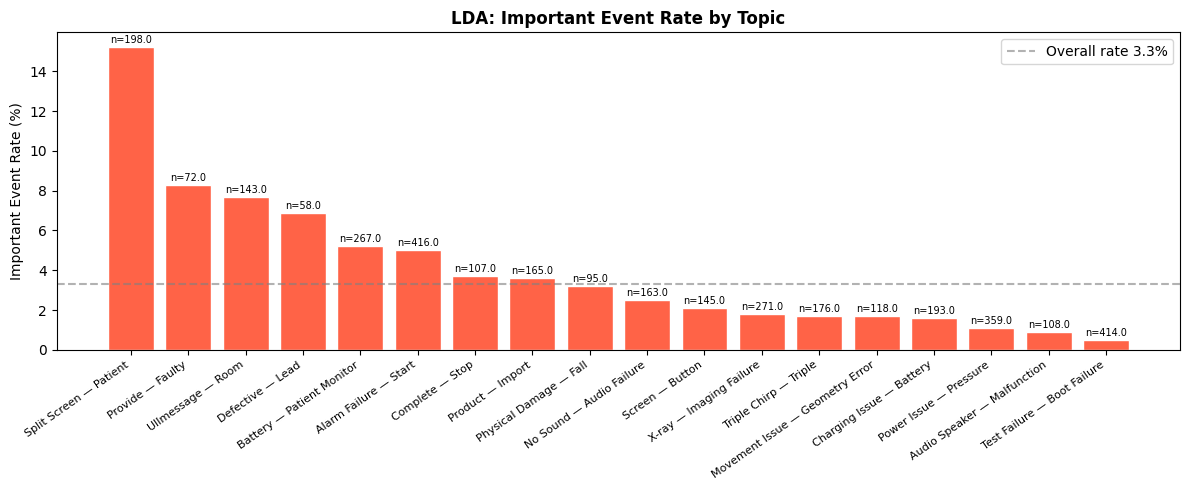

Saved: lda_event_rate.png


In [11]:
# Event rate bar chart per LDA topic
fig, ax = plt.subplots(figsize=(12,5))
bars = ax.bar(lda_event_rate['lda_topic_label'], lda_event_rate['event_rate_%'],
              color='tomato', edgecolor='white')
for bar, n in zip(bars, lda_event_rate['n_records']):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1,
            f'n={n}', ha='center', va='bottom', fontsize=7)
ax.axhline(3.3, linestyle='--', color='gray', alpha=0.6, label='Overall rate 3.3%')
ax.set_xticklabels(lda_event_rate['lda_topic_label'], rotation=35, ha='right', fontsize=8)
ax.set_ylabel('Important Event Rate (%)')
ax.set_title('LDA: Important Event Rate by Topic', fontweight='bold')
ax.legend(); plt.tight_layout()
plt.savefig('lda_event_rate.png', dpi=150); plt.show()
print('Saved: lda_event_rate.png')

## Part B — BERTopic

In [12]:
# ── BERTopic — FIXED VERSION ─────────────────────────────────────────────
#
# Root causes of old problems:
#   1. build_rich_text used raw notes_clean which still had anonymization
#      artifacts ("By Engineer", "ue", "faut", "Cutomer") → HDBSCAN clusters
#      around those noise words instead of actual fault types
#   2. min_cluster_size=25 on 4000 docs → 42 micro-clusters (too granular)
#   3. CountVectorizer stop list too short, artifact words leaked into labels
#
# Fixes applied:
#   1. Use ONLY desc1_clean_bert (already cleaned) — drop polluted notes
#      for embedding input. notes_problem_desc added only if it passes a
#      strict artifact filter.
#   2. min_cluster_size=60 → 12-18 meaningful clusters for ~4000 docs
#   3. nr_topics='auto' → BERTopic merges semantically similar micro-clusters
#   4. Massively extended stop list for vectorizer labels

import re

# ── Artifact filter for notes_problem_desc ───────────────────────────────
# Only append problem desc if it doesn't look like raw template noise
ARTIFACT_PATTERNS = re.compile(
    r'(by engineer|cutomer|eupected|resuts|resoluion|faction|'
    r'ueupected|touhscreen|\[id\]|redacted|\bue\b|\bfaut\b)',
    re.IGNORECASE
)

def build_clean_bert_input(row):
    """Only use desc1_clean_bert + problem_desc if problem_desc is clean enough."""
    d = str(row['desc1_clean_bert']).strip()
    if d == 'nan': d = ''
    p = str(row.get('notes_problem_desc', '')).strip()
    # Reject problem_desc if it still has too many artifacts
    if p and p != 'nan' and len(p) > 15:
        artifact_hits = len(ARTIFACT_PATTERNS.findall(p))
        word_count    = len(p.split())
        artifact_ratio= artifact_hits / max(word_count, 1)
        if artifact_ratio < 0.15:   # < 15% artifact words → safe to use
            d = d + ' ' + p[:300]
    return d.strip() if d.strip() else 'no description'

bert_corpus_clean = df.apply(build_clean_bert_input, axis=1).tolist()

# Filter short rows
bert_valid_idx  = [i for i, t in enumerate(bert_corpus_clean) if len(t.split()) >= 2]
bert_corpus     = [bert_corpus_clean[i] for i in bert_valid_idx]
print(f'BERTopic input rows: {len(bert_corpus)}')
print(f'Sample (first 3):')
for t in bert_corpus[:3]: print(' ', t[:120])

# ── Load embedding model ──────────────────────────────────────────────────
print('\nLoading sentence-transformer...')
embedding_model = SentenceTransformer('all-mpnet-base-v2')

# ── UMAP: keep n_components low so HDBSCAN works well ────────────────────
umap_model = UMAP(
    n_neighbors=15,       # higher = more global structure, fewer tiny clusters
    n_components=5,       # lower dims = cleaner HDBSCAN boundaries
    min_dist=0.0,
    metric='cosine',
    random_state=42
)

# ── HDBSCAN: min_cluster_size is THE key parameter ───────────────────────
# Rule of thumb: ~1-2% of corpus size for medical/technical text
# 4000 docs → min_cluster_size=60 → expect ~10-18 meaningful clusters
hdbscan_model = HDBSCAN(
    min_cluster_size=60,  # was 25 → caused 42 micro-clusters
    min_samples=10,       # higher = fewer noise points forced into clusters
    metric='euclidean',
    cluster_selection_method='eom',
    prediction_data=True
)

# ── Extended stop list for vectorizer labels ──────────────────────────────
# Must block ALL artifact words so they never appear in topic labels
GENERIC_WORDS = [
    # Generic failure words
    'failed','failure','fail','fails','failing','malfunction','malfunctioning',
    'error','faulty','issue','problem','unable','cannot','defective','broken',
    'repair','device','unit','equipment','work','working','occurred','fault',
    'diagnosis','diagnose',
    # Anonymization artifacts from notes
    'customer','cutomer','engineer','by','ue','faut','impact','results',
    'expected','unexpected','description','fuction','function','role',
    'biomed','clinical','result','resuts','resoluion','eupected','ueupected',
    'faction','na','nan','no','yes','none','unknown','use','used','using',
    'id','redacted','the','and','is','of','to','in','for','with','are',
    'was','not','this','that','performed','device','patient','our','ur',
    'se','an','pi','npi','ue','new','old','case','call','report',
]

vec_model = CountVectorizer(
    stop_words=GENERIC_WORDS,
    ngram_range=(1, 2),
    min_df=5
)

# ── BERTopic with nr_topics to merge similar micro-clusters ──────────────
topic_model = BERTopic(
    embedding_model=embedding_model,
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    vectorizer_model=vec_model,
    representation_model=KeyBERTInspired(),
    top_n_words=10,
    nr_topics='auto',    # KEY FIX: merges semantically similar clusters automatically
    verbose=True
)

print('Fitting BERTopic...')
topics, probs = topic_model.fit_transform(bert_corpus)

# Reassign outliers to nearest cluster via embedding similarity
new_topics = topic_model.reduce_outliers(
    bert_corpus, topics, strategy='embeddings', threshold=0.5
)
topic_model.update_topics(bert_corpus, topics=new_topics)
topics = new_topics

n_topics = len(set(t for t in topics if t != -1))
noise_pct = (np.array(topics) == -1).mean() * 100
print(f'\nFound {n_topics} topics  (noise ratio: {noise_pct:.1f}%)')
print(topic_model.get_topic_freq().head(25).to_string(index=False))


BERTopic input rows: 3992
Sample (first 3):
  battery request by Engineer: Customer Function/Role: Biomedical
 Device u
  paddle plate is not working by Engineer: Customer Function/Role: Clinical Engineer
 Device u
  alarms no sound no sound alarm anymore no trouble found ur configuration provided information by Engineer: Customer Func

Loading sentence-transformer...


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 4331.14it/s]
MPNetModel LOAD REPORT from: sentence-transformers/all-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
2026-04-04 21:54:07,015 - BERTopic - Embedding - Transforming documents to embeddings.


Fitting BERTopic...


Batches: 100%|██████████| 125/125 [03:25<00:00,  1.64s/it]
2026-04-04 21:57:32,513 - BERTopic - Embedding - Completed ✓
2026-04-04 21:57:32,515 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-04-04 21:58:17,778 - BERTopic - Dimensionality - Completed ✓
2026-04-04 21:58:17,780 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-04-04 21:58:17,871 - BERTopic - Cluster - Completed ✓
2026-04-04 21:58:17,872 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2026-04-04 21:58:17,977 - BERTopic - Representation - Completed ✓
2026-04-04 21:58:17,978 - BERTopic - Topic reduction - Reducing number of topics
2026-04-04 21:58:17,986 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-04-04 21:58:24,822 - BERTopic - Representation - Completed ✓
2026-04-04 21:58:24,825 - BERTopic - Topic reduction - Reduced number of topics from 21 to 21
2026-04-04 21:58:38,872 - BERTopic - WARNING: Usin


Found 20 topics  (noise ratio: 5.4%)
 Topic  Count
     0    383
     2    277
     4    263
     1    245
     3    229
     5    219
    -1    217
     8    216
     7    212
     6    209
    13    197
    10    176
     9    172
    12    164
    11    157
    16    148
    15    122
    14    120
    17    104
    18     87
    19     75


In [13]:
# ── Improved BERTopic auto-labeller ──────────────────────────────────────
#
# Improvement over old code:
# 1. Uses c-TF-IDF score weighting — rare but distinctive words rank higher
#    than just frequent words. This gives topic-specific terms priority.
# 2. Applies same DOMAIN_MAP as LDA for consistent terminology
# 3. Filters noise words including new artifacts found in analysis
# 4. Investigates the 'Noise' cluster to give it a meaningful label

BERT_LABEL_STOP = set(GENERIC_LABEL_WORDS) | {
    'not','no','nan','yes','none','id','redacted','the','and','is','of',
    'to','in','for','with','are','was','this','that','performed','our',
    'ur','se','an','pi','npi','ue','case','call','report','by','engineer',
    'fuction','role','biomed','clinical','device','unit','customer','cutomer',
    'impact','results','expected','unexpected','description','resolution',
    'faut','udfm','hw','found','not','does','up','start',
}

def improved_bert_label(topic_model, topic_id, corpus_texts, doc_indices):
    """
    Uses c-TF-IDF top words (already computed by BERTopic's KeyBERTInspired)
    which ranks words by their distinctiveness to this topic vs all topics.
    This surfaces rare but topic-specific terms over generic frequent ones.
    """
    if topic_id == -1:
        # Analyse noise cluster — find its most common words to give it a real label
        noise_texts = [corpus_texts[i] for i in doc_indices]
        from sklearn.feature_extraction.text import CountVectorizer
        try:
            vec = CountVectorizer(max_features=20, stop_words=list(BERT_LABEL_STOP))
            vec.fit(noise_texts)
            top_noise = vec.get_feature_names_out()[:3]
            if top_noise:
                return 'Unclassified — ' + ' / '.join([DOMAIN_MAP.get(w, w.title()) for w in top_noise])
        except:
            pass
        return 'Unclassified'

    # Get KeyBERT-inspired top words (c-TF-IDF weighted)
    word_scores = topic_model.get_topic(topic_id)
    
    mapped = []
    seen   = set()
    for word, score in word_scores:
        w = word.lower().strip()
        # Filter: must be alpha, not in stop list, length > 2
        if w in BERT_LABEL_STOP: continue
        if not w.isalpha(): continue
        if len(w) <= 2: continue
        if w.startswith('0') or w.startswith('u') and len(w) < 4: continue
        # Map to domain term
        mapped_word = DOMAIN_MAP.get(w, word.title())
        if mapped_word not in seen:
            mapped.append((mapped_word, score))
            seen.add(mapped_word)
        if len(mapped) >= 3: break
    
    if not mapped:
        return f'BERTopic {topic_id}'
    
    # Format: first term is device/component, second is symptom where possible
    if len(mapped) >= 2:
        return f'{mapped[0][0]} — {mapped[1][0]}'
    return mapped[0][0]

BERT_TOPIC_LABELS = {}
for topic_id in sorted(set(topics)):
    doc_indices = [i for i, t in enumerate(topics) if t == topic_id]
    BERT_TOPIC_LABELS[topic_id] = improved_bert_label(
        topic_model, topic_id, bert_corpus, doc_indices
    )

print('Improved BERTopic labels:')
for k, v in sorted(BERT_TOPIC_LABELS.items()):
    if k == -1: continue
    word_scores = topic_model.get_topic(k)
    words_str   = ', '.join([w for w, _ in word_scores[:6]])
    n_docs      = (np.array(topics) == k).sum()
    print(f'  Topic {k:3d} ({n_docs:4d} docs) → "{v}"')
    print(f'             c-TF-IDF words: {words_str}')

print(f'\nNoise cluster label: {BERT_TOPIC_LABELS.get(-1, "Unclassified")}')


Improved BERTopic labels:
  Topic   0 ( 383 docs) → "Function"
             c-TF-IDF words: ue, device, impact, uer, no, role
  Topic   1 ( 245 docs) → "Battery — Charging Issue"
             c-TF-IDF words: battery, charge, charging, ue, not, and
  Topic   2 ( 277 docs) → "Pressure — Alarm Failure"
             c-TF-IDF words: pressure, alarm, vent, sensor, failed, biomed
  Topic   3 ( 229 docs) → "Audio Speaker — Audio Failure"
             c-TF-IDF words: speaker, audio, hw, sound, no, replaced
  Topic   4 ( 263 docs) → "Complaint — Handling"
             c-TF-IDF words: information, complaint, the, handling, process, description
  Topic   5 ( 219 docs) → "Self-Test — Test Failure"
             c-TF-IDF words: m0a, u00, self, test, 00, qa
  Topic   6 ( 209 docs) → "Geometry Error — Imaging Arm"
             c-TF-IDF words: geometry, arm, movement, the, move, movements
  Topic   7 ( 212 docs) → "Patient Monitor — Display"
             c-TF-IDF words: monitor, display, screen, fleuvis

### ✏️ Optional: Override auto-labels after reading the output above
```python
# Example:
BERT_TOPIC_LABELS[0] = 'Battery Charge'
BERT_TOPIC_LABELS[1] = 'Alarm Audio'
```

In [14]:
# ── Assign BERTopic back to dataframe ─────────────────────────────────────
df['bert_topic_id']    = pd.Series(topics, index=bert_valid_idx)
df['bert_topic_label'] = df['bert_topic_id'].map(BERT_TOPIC_LABELS)
df['bert_topic_prob']  = pd.Series([round(float(p),4) if hasattr(p,'__float__') else 0.0
                                    for p in probs], index=bert_valid_idx)
print('BERTopic distribution:')
print(df['bert_topic_label'].value_counts().head(25))

BERTopic distribution:
bert_topic_label
Function                           383
Pressure — Alarm Failure           277
Complaint — Handling               263
Battery — Charging Issue           245
Audio Speaker — Audio Failure      229
Self-Test — Test Failure           219
Unclassified                       217
Boot Failure                       216
Patient Monitor — Display          212
Geometry Error — Imaging Arm       209
Power Issue                        197
Alarm Failure — Alarms             176
AED — Triple                       172
Defibrillator — Patient Monitor    164
X-ray — Problem                    157
Action — Key                       148
Touchscreen — Touch                122
Wireless — Footswitch              120
Disk Full — Imaging Failure        104
Cable — Paddle                      87
Fluoroscopy — Fluro                 75
Name: count, dtype: int64


In [15]:
# ── BERTopic: Important Event rate per topic ─────────────────────────────
bert_event_rate = df[
    df['Important Event'].isin(['Yes','No']) & df['bert_topic_label'].notna()
].groupby('bert_topic_label').apply(
    lambda g: pd.Series({
        'n_records': len(g),
        'n_important': (g['Important Event'] == 'Yes').sum(),
        'event_rate_%': round((g['Important Event'] == 'Yes').mean() * 100, 1)
    })
).sort_values('event_rate_%', ascending=False).reset_index()

print('BERTopic — Important Event Rate per Topic:')
print(bert_event_rate.head(20).to_string(index=False))

BERTopic — Important Event Rate per Topic:
               bert_topic_label  n_records  n_important  event_rate_%
         Alarm Failure — Alarms      173.0         35.0          20.2
                   Unclassified      211.0         20.0           9.5
Defibrillator — Patient Monitor      164.0         13.0           7.9
                       Function      382.0         19.0           5.0
       Pressure — Alarm Failure      277.0         10.0           3.6
                   AED — Triple      170.0          6.0           3.5
       Self-Test — Test Failure      218.0          7.0           3.2
      Patient Monitor — Display      212.0          6.0           2.8
            Fluoroscopy — Fluro       74.0          2.0           2.7
                 Cable — Paddle       87.0          2.0           2.3
    Disk Full — Imaging Failure      104.0          2.0           1.9
           Complaint — Handling      263.0          4.0           1.5
   Geometry Error — Imaging Arm      208.0     

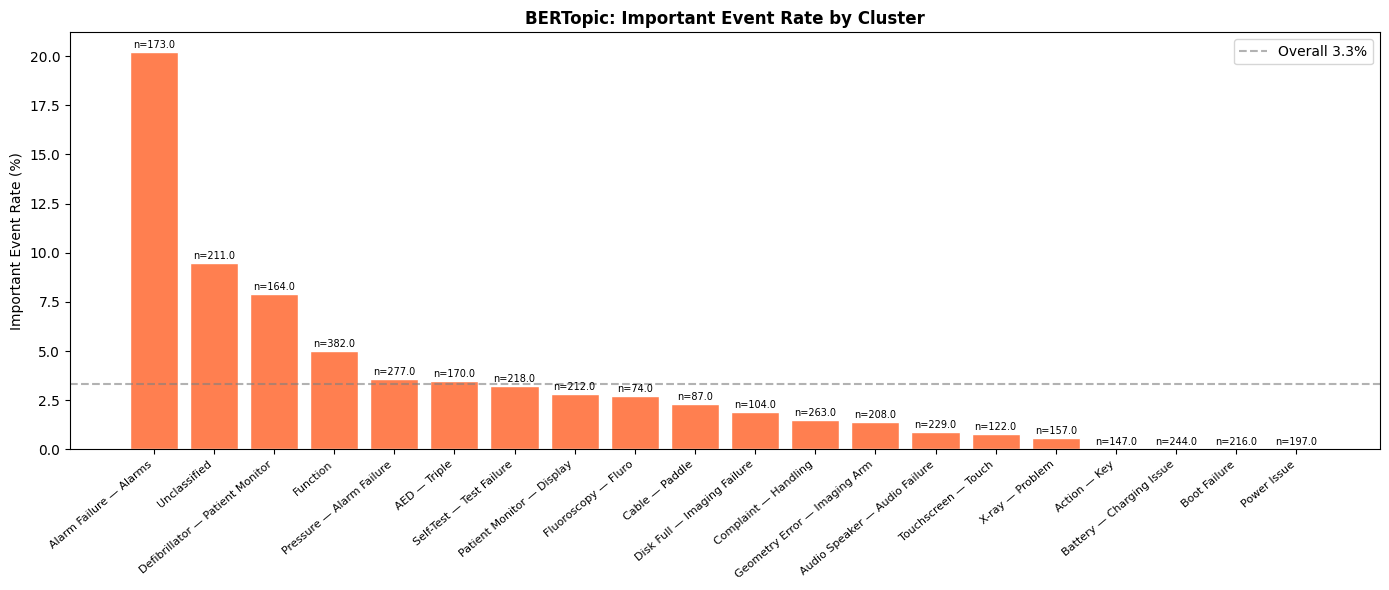

Saved: bertopic_event_rate.png


In [16]:
# ── BERTopic visualisations ───────────────────────────────────────────────
# Event rate bar chart
top_bert = bert_event_rate[bert_event_rate['bert_topic_label'] != 'Noise / Unclassified'].head(20)
fig, ax = plt.subplots(figsize=(14,6))
bars = ax.bar(top_bert['bert_topic_label'], top_bert['event_rate_%'],
              color='coral', edgecolor='white')
for bar, n in zip(bars, top_bert['n_records']):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1,
            f'n={n}', ha='center', va='bottom', fontsize=7)
ax.axhline(3.3, linestyle='--', color='gray', alpha=0.6, label='Overall 3.3%')
ax.set_xticklabels(top_bert['bert_topic_label'], rotation=40, ha='right', fontsize=8)
ax.set_ylabel('Important Event Rate (%)')
ax.set_title('BERTopic: Important Event Rate by Cluster', fontweight='bold')
ax.legend(); plt.tight_layout()
plt.savefig('bertopic_event_rate.png', dpi=150); plt.show()
print('Saved: bertopic_event_rate.png')

In [17]:
# Interactive BERTopic plots (open HTML files in browser)
try:
    fig_topics = topic_model.visualize_topics()
    fig_topics.write_html('bertopic_intertopic.html')
    print('Saved: bertopic_intertopic.html')
except Exception as e:
    print(f'Skipped interactive plot: {e}')
try:
    fig_hier = topic_model.visualize_hierarchy()
    fig_hier.write_html('bertopic_hierarchy.html')
    print('Saved: bertopic_hierarchy.html')
except Exception as e:
    print(f'Skipped hierarchy plot: {e}')

Saved: bertopic_intertopic.html
Saved: bertopic_hierarchy.html


In [18]:
# ── Side-by-side comparison: LDA vs BERTopic ─────────────────────────────
print('=== MODEL COMPARISON ===')
print(f'LDA  coherence (c_v):  {max(coherence_scores):.4f}')
bert_noise_pct = (np.array(topics)==-1).mean()*100
print(f'BERTopic noise ratio:  {bert_noise_pct:.1f}%')
print(f'LDA  topics: {BEST_K}')
print(f'BERTopic topics: {len(set(t for t in topics if t != -1))}')
print()
print('Top 5 HIGH-RISK topics — LDA:')
print(lda_event_rate.head(5)[['lda_topic_label','n_records','event_rate_%']].to_string(index=False))
print('\nTop 5 HIGH-RISK topics — BERTopic:')
print(bert_event_rate.head(5)[['bert_topic_label','n_records','event_rate_%']].to_string(index=False))

=== MODEL COMPARISON ===
LDA  coherence (c_v):  0.5147
BERTopic noise ratio:  5.4%
LDA  topics: 18
BERTopic topics: 20

Top 5 HIGH-RISK topics — LDA:
          lda_topic_label  n_records  event_rate_%
   Split Screen — Patient      198.0          15.2
         Provide — Faulty       72.0           8.3
        Ullmessage — Room      143.0           7.7
         Defective — Lead       58.0           6.9
Battery — Patient Monitor      267.0           5.2

Top 5 HIGH-RISK topics — BERTopic:
               bert_topic_label  n_records  event_rate_%
         Alarm Failure — Alarms      173.0          20.2
                   Unclassified      211.0           9.5
Defibrillator — Patient Monitor      164.0           7.9
                       Function      382.0           5.0
       Pressure — Alarm Failure      277.0           3.6


Computing all clustering metrics...

[1/9] Computing coherence scores...
  LDA  coherence (c_v): 0.5145
  BERT coherence (c_v): 0.6266
  Topics used for BERT coherence: 20 / 20

[2/9] Computing topic diversity...
  LDA  diversity: 0.8222  (1.0 = all words unique across topics)
  BERT diversity: 0.6350

[3/9] Computing silhouette scores...


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 5891.21it/s]
MPNetModel LOAD REPORT from: sentence-transformers/all-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  Embedding 800 sampled docs...


Batches: 100%|██████████| 7/7 [00:19<00:00,  2.83s/it]


  LDA  silhouette: 0.5262  (>0.5 = well separated)
  BERT silhouette: 0.1205

[4/9] Computing topic size balance...
  LDA  size balance: 0.9499  (1.0 = perfectly even)
  BERT size balance: 0.9765

[5/9] Computing Important Event concentration...
  LDA  event Gini: 0.4391  | top-3 coverage: 51.6%
  BERT event Gini: 0.6226  | top-3 coverage: 59.3%

[6/9] Computing topic purity...
  Baseline (all-No): 0.9666
  LDA  purity: 0.9637  adjusted: -0.0878
  BERT purity: 0.9700  adjusted: 0.0000

[7/9] Computing intra-topic coherence...
  LDA  mean intra-topic similarity: 0.7745
  BERT mean intra-topic similarity: 0.4924

[8/9] Coverage...
  LDA  coverage: 87.1%
  BERT coverage: 94.6%  (noise=217 docs)

[9/9] LDA perplexity...
  LDA log-perplexity: -5.9410  perplexity: 380.33

CLUSTERING EVALUATION SUMMARY
  Metric                              LDA   BERTopic   Better
  ------------------------------------------------------------
  Coherence (c_v)       ↑          0.5145     0.6266     BERT
  Topi

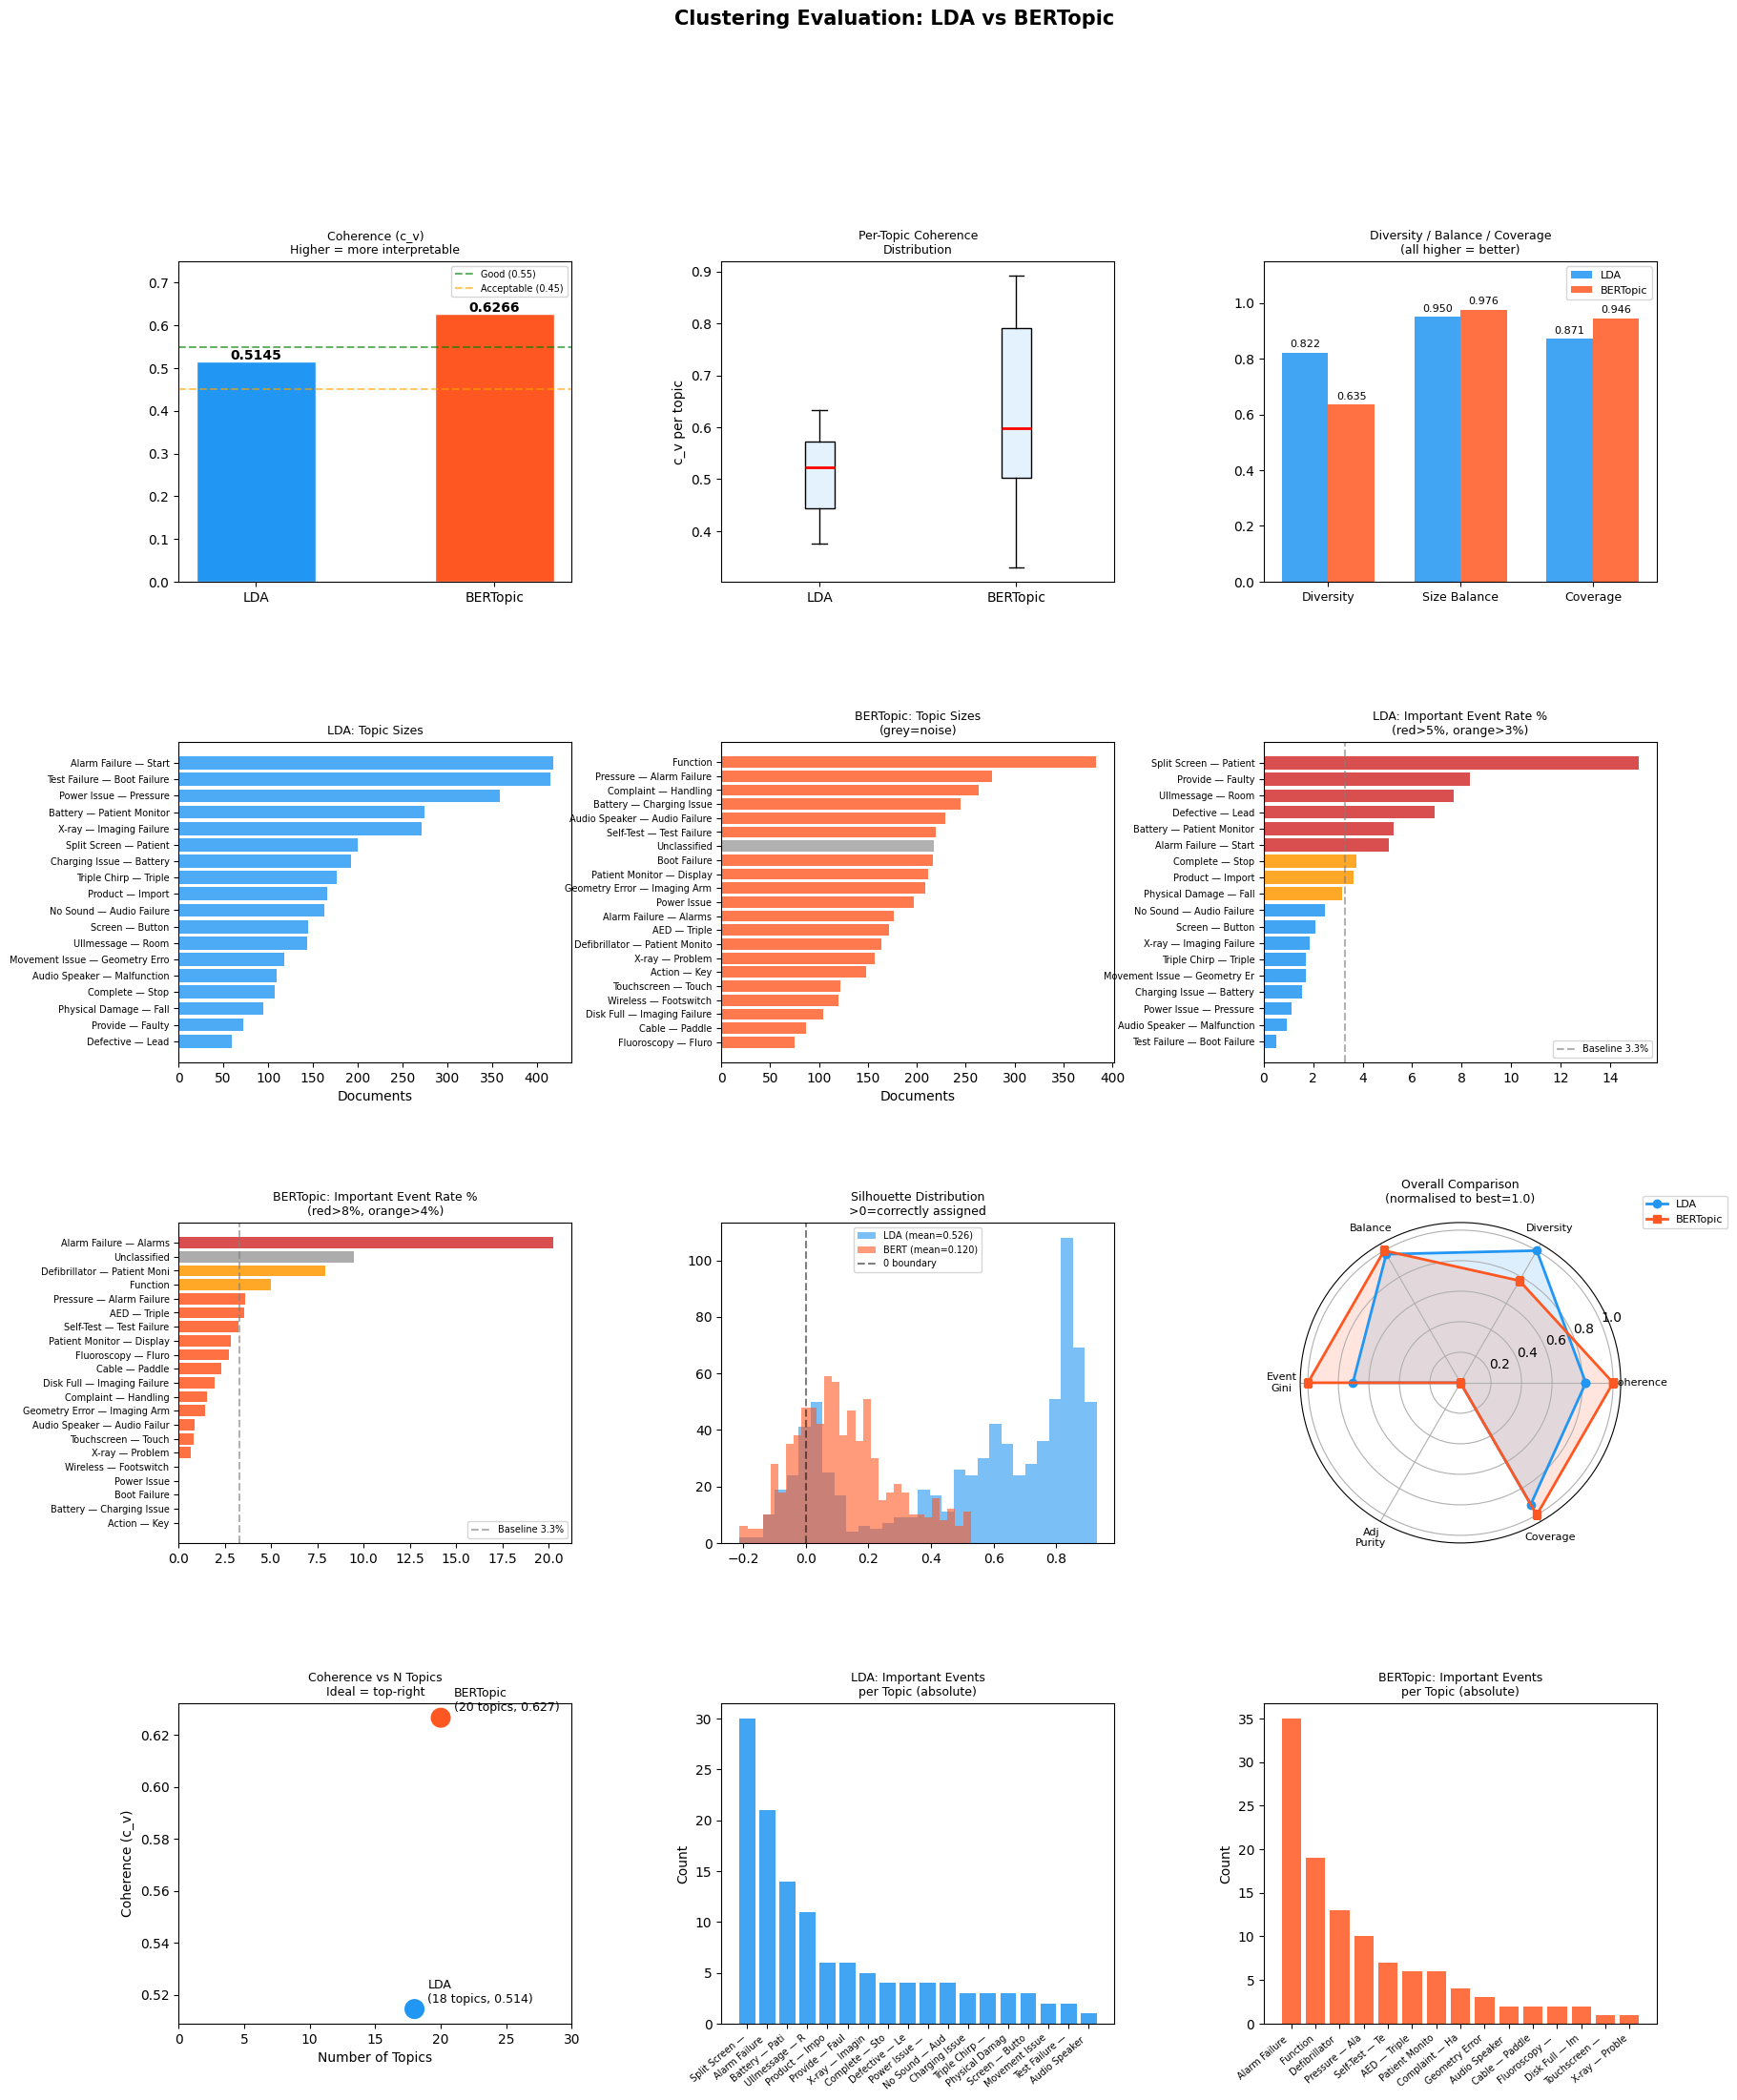


Saved: clustering_evaluation.png

METRIC INTERPRETATION GUIDE
  Coherence (c_v)       : Do top words of each topic co-occur in real docs? Good>0.55, OK>0.45
  Topic Diversity       : Fraction of unique words across all topics. Low=topics overlap too much.
  Silhouette            : Cluster separation. >0.5=well separated. Negative=wrong cluster.
  Size Balance          : Normalised entropy of topic sizes. 1.0=all same size. 0=one huge topic.
  Event Gini            : How concentrated are Important Events in few topics? High=more actionable.
  Top-3 Coverage        : % of all Important Events in the 3 highest-risk topics.
  Adjusted Purity       : Topic separation above naive baseline. Positive=better than all-No.
  Intra-Topic Sim       : Avg cosine similarity within each topic. Higher=tighter, more focused.
  Coverage              : % of documents assigned to a topic (vs left unclustered).
  Log-Perplexity        : LDA only. How well model predicts held-out words. Lower=better fit.


In [21]:
# ══════════════════════════════════════════════════════════════════════════
# CLUSTERING EVALUATION: LDA vs BERTopic
# ══════════════════════════════════════════════════════════════════════════
# Run AFTER all LDA and BERTopic cells have completed.
# Requires: lda_model, corpus_bow, tokenized, id2word, BEST_K,
#           topic_model, topics, bert_corpus, bert_valid_idx,
#           lda_valid_idx, df, LDA_TOPIC_LABELS, BERT_TOPIC_LABELS

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from gensim.models import CoherenceModel
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.preprocessing import normalize
from collections import Counter

print('Computing all clustering metrics...')
print('=' * 65)

# ── 1. COHERENCE (c_v) ───────────────────────────────────────────────────
print('\n[1/9] Computing coherence scores...')

lda_coh_model  = CoherenceModel(model=lda_model, texts=tokenized,
                                 dictionary=id2word, coherence='c_v')
lda_coherence      = lda_coh_model.get_coherence()
lda_per_topic_coh  = lda_coh_model.get_coherence_per_topic()

# BERTopic coherence — use its own dictionary, not LDA's id2word
bert_tokenized = [t.split() for t in bert_corpus]
valid_bert_ids = sorted([t for t in set(topics) if t != -1])

# Build a fresh dictionary from BERTopic's input texts
import gensim.corpora as corpora
bert_dictionary = corpora.Dictionary(bert_tokenized)
bert_dictionary.filter_extremes(no_below=2, no_above=0.8)

bert_word_lists_coh = []
for tid in valid_bert_ids:
    # Get words and filter to only those present in bert_dictionary
    raw_words = [w for w, _ in topic_model.get_topic(tid)
                 if ' ' not in w and len(w) > 2]
    # Keep only words the dictionary knows about
    valid_words = [w for w in raw_words if w in bert_dictionary.token2id][:10]
    if len(valid_words) >= 2:   # need at least 2 words for coherence
        bert_word_lists_coh.append(valid_words)

if bert_word_lists_coh:
    bert_coh_model = CoherenceModel(
        topics=bert_word_lists_coh,
        texts=bert_tokenized,
        dictionary=bert_dictionary,
        coherence='c_v'
    )
    bert_coherence     = bert_coh_model.get_coherence()
    bert_per_topic_coh = bert_coh_model.get_coherence_per_topic()
else:
    print('  Warning: no valid BERTopic word lists — setting coherence to 0')
    bert_coherence     = 0.0
    bert_per_topic_coh = []

print(f'  LDA  coherence (c_v): {lda_coherence:.4f}')
print(f'  BERT coherence (c_v): {bert_coherence:.4f}')
print(f'  Topics used for BERT coherence: {len(bert_word_lists_coh)} / {len(valid_bert_ids)}')

# ── 2. TOPIC DIVERSITY ────────────────────────────────────────────────────
print('\n[2/9] Computing topic diversity...')

def topic_diversity(topic_word_lists, top_n=10):
    all_words = []
    for wlist in topic_word_lists:
        all_words.extend(wlist[:top_n])
    return len(set(all_words)) / len(all_words) if all_words else 0.0

lda_word_lists  = [[w for w,_ in lda_model.show_topic(i, topn=10)] for i in range(BEST_K)]
bert_word_lists = [[w for w,_ in topic_model.get_topic(t)] for t in valid_bert_ids]

lda_diversity  = topic_diversity(lda_word_lists)
bert_diversity = topic_diversity(bert_word_lists)
print(f'  LDA  diversity: {lda_diversity:.4f}  (1.0 = all words unique across topics)')
print(f'  BERT diversity: {bert_diversity:.4f}')

# ── 3. SILHOUETTE SCORE ───────────────────────────────────────────────────
print('\n[3/9] Computing silhouette scores...')
sil_computed = False
lda_sil = bert_sil = None
lda_sil_samples = bert_sil_samples = np.array([])

try:
    from sentence_transformers import SentenceTransformer
    sent_eval = SentenceTransformer('all-mpnet-base-v2')

    np.random.seed(42)
    n_sample = min(800, len(bert_corpus))
    s_idx    = np.random.choice(len(bert_corpus), n_sample, replace=False)
    s_texts  = [bert_corpus[i] for i in s_idx]
    s_topics = [topics[i] for i in s_idx]

    print(f'  Embedding {n_sample} sampled docs...')
    s_embs      = sent_eval.encode(s_texts, batch_size=128, show_progress_bar=True)
    s_embs_norm = normalize(s_embs)

    # BERTopic silhouette (exclude noise)
    mask = np.array(s_topics) != -1
    if mask.sum() > 10:
        bert_sil = float(silhouette_score(s_embs_norm[mask], np.array(s_topics)[mask], metric='cosine'))
        bert_sil_samples = silhouette_samples(s_embs_norm[mask], np.array(s_topics)[mask], metric='cosine')

    # LDA silhouette — use topic probability vectors as document representation
    lda_mat = np.zeros((len(corpus_bow), BEST_K))
    for di, bow in enumerate(corpus_bow):
        for tid, prob in lda_model.get_document_topics(bow, minimum_probability=0):
            lda_mat[di, tid] = prob

    l_idx    = np.random.choice(len(corpus_bow), n_sample, replace=False)
    l_mat    = lda_mat[l_idx]
    l_labels = l_mat.argmax(axis=1)
    lda_sil  = float(silhouette_score(l_mat, l_labels, metric='cosine'))
    lda_sil_samples = silhouette_samples(l_mat, l_labels, metric='cosine')

    sil_computed = True
    print(f'  LDA  silhouette: {lda_sil:.4f}  (>0.5 = well separated)')
    print(f'  BERT silhouette: {bert_sil:.4f}')

except Exception as e:
    print(f'  Silhouette skipped: {e}')

# ── 4. TOPIC SIZE BALANCE ─────────────────────────────────────────────────
print('\n[4/9] Computing topic size balance...')

def size_balance(counts_dict):
    counts = np.array(list(counts_dict.values()), dtype=float)
    counts /= counts.sum()
    H = -np.sum(counts * np.log(counts + 1e-10))
    return H / np.log(len(counts)) if len(counts) > 1 else 0.0

lda_counts  = df['lda_topic_label'].value_counts().to_dict()
bert_counts = {k: v for k,v in df['bert_topic_label'].value_counts().to_dict().items()
               if 'Unclassified' not in str(k)}

lda_balance  = size_balance(lda_counts)
bert_balance = size_balance(bert_counts)
print(f'  LDA  size balance: {lda_balance:.4f}  (1.0 = perfectly even)')
print(f'  BERT size balance: {bert_balance:.4f}')

# ── 5. IMPORTANT EVENT CONCENTRATION ─────────────────────────────────────
print('\n[5/9] Computing Important Event concentration...')

def event_gini(df_in, label_col):
    grp   = df_in[df_in['Important Event'].isin(['Yes','No'])].groupby(label_col)
    rates = np.sort(grp.apply(lambda g: (g['Important Event']=='Yes').mean()).values)
    n     = len(rates)
    if n == 0 or rates.sum() == 0: return 0.0
    idx   = np.arange(1, n+1)
    return float((2*np.sum(idx*rates)) / (n*rates.sum()) - (n+1)/n)

def top3_coverage(df_in, label_col):
    grp     = df_in[df_in['Important Event'].isin(['Yes','No'])].groupby(label_col)
    yes_cnt = grp.apply(lambda g: (g['Important Event']=='Yes').sum())
    total   = yes_cnt.sum()
    return float(yes_cnt.nlargest(3).sum() / total) if total > 0 else 0.0

lda_gini  = event_gini(df, 'lda_topic_label')
bert_gini = event_gini(df[~df['bert_topic_label'].str.contains('Unclassified', na=True)],
                        'bert_topic_label')
lda_top3  = top3_coverage(df, 'lda_topic_label')
bert_top3 = top3_coverage(df[~df['bert_topic_label'].str.contains('Unclassified', na=True)],
                           'bert_topic_label')

print(f'  LDA  event Gini: {lda_gini:.4f}  | top-3 coverage: {lda_top3*100:.1f}%')
print(f'  BERT event Gini: {bert_gini:.4f}  | top-3 coverage: {bert_top3*100:.1f}%')

# ── 6. TOPIC PURITY ───────────────────────────────────────────────────────
print('\n[6/9] Computing topic purity...')

def topic_purity(df_in, label_col):
    sub      = df_in[df_in['Important Event'].isin(['Yes','No'])]
    baseline = (sub['Important Event']=='No').mean()
    total, wpurity = 0, 0.0
    for _, grp in sub.groupby(label_col):
        n      = len(grp)
        yes    = (grp['Important Event']=='Yes').mean()
        wpurity += max(yes, 1-yes) * n
        total   += n
    raw = wpurity / total if total > 0 else 0.0
    adj = (raw - baseline) / (1 - baseline) if baseline < 1 else 0.0
    return raw, adj

lda_purity,  lda_adj  = topic_purity(df, 'lda_topic_label')
bert_purity, bert_adj = topic_purity(
    df[~df['bert_topic_label'].str.contains('Unclassified', na=True)], 'bert_topic_label')

baseline = (df[df['Important Event'].isin(['Yes','No'])]['Important Event']=='No').mean()
print(f'  Baseline (all-No): {baseline:.4f}')
print(f'  LDA  purity: {lda_purity:.4f}  adjusted: {lda_adj:.4f}')
print(f'  BERT purity: {bert_purity:.4f}  adjusted: {bert_adj:.4f}')

# ── 7. INTRA-TOPIC COHERENCE ─────────────────────────────────────────────
print('\n[7/9] Computing intra-topic coherence...')

def intra_sim(embs_norm, labels, exclude=-1):
    scores = {}
    np.random.seed(42)
    for tid in set(labels):
        if tid == exclude: continue
        mask = np.array(labels) == tid
        te   = embs_norm[mask]
        if len(te) < 2: continue
        if len(te) > 80:
            te = te[np.random.choice(len(te), 80, replace=False)]
        sim = te @ te.T
        upper = sim[np.triu_indices(len(te), k=1)]
        scores[tid] = float(upper.mean())
    return scores

if sil_computed:
    lda_intra      = intra_sim(l_mat / (np.linalg.norm(l_mat, axis=1, keepdims=True) + 1e-9), l_labels)
    lda_intra_mean = np.mean(list(lda_intra.values()))
    bert_intra     = intra_sim(s_embs_norm, np.array(s_topics))
    bert_intra_mean= np.mean(list(bert_intra.values()))
    print(f'  LDA  mean intra-topic similarity: {lda_intra_mean:.4f}')
    print(f'  BERT mean intra-topic similarity: {bert_intra_mean:.4f}')
else:
    lda_intra_mean = bert_intra_mean = None
    print('  Skipped (needs embeddings)')

# ── 8. COVERAGE + NOISE ───────────────────────────────────────────────────
print('\n[8/9] Coverage...')
lda_coverage  = len(lda_valid_idx) / len(df)
bert_noise_n  = (np.array(topics) == -1).sum()
bert_coverage = 1 - bert_noise_n / len(bert_valid_idx)
print(f'  LDA  coverage: {lda_coverage*100:.1f}%')
print(f'  BERT coverage: {bert_coverage*100:.1f}%  (noise={bert_noise_n} docs)')

# ── 9. LDA PERPLEXITY ─────────────────────────────────────────────────────
print('\n[9/9] LDA perplexity...')
lda_log_perp = lda_model.log_perplexity(corpus_bow)
print(f'  LDA log-perplexity: {lda_log_perp:.4f}  perplexity: {np.exp(-lda_log_perp):.2f}')

# ══════════════════════════════════════════════════════════════════════════
# SUMMARY TABLE
# ══════════════════════════════════════════════════════════════════════════
print('\n' + '='*65)
print('CLUSTERING EVALUATION SUMMARY')
print('='*65)

rows = [
    ('Coherence (c_v)       ↑', f'{lda_coherence:.4f}',  f'{bert_coherence:.4f}',
     'BERT' if bert_coherence > lda_coherence else 'LDA'),
    ('Topic Diversity       ↑', f'{lda_diversity:.4f}',  f'{bert_diversity:.4f}',
     'BERT' if bert_diversity > lda_diversity else 'LDA'),
    ('Silhouette Score      ↑',
     f'{lda_sil:.4f}'  if lda_sil  else 'N/A',
     f'{bert_sil:.4f}' if bert_sil else 'N/A',
     'BERT' if (bert_sil or 0) > (lda_sil or 0) else 'LDA'),
    ('Size Balance          ↑', f'{lda_balance:.4f}',  f'{bert_balance:.4f}',
     'BERT' if bert_balance > lda_balance else 'LDA'),
    ('Event Gini Coeff      ↑', f'{lda_gini:.4f}',  f'{bert_gini:.4f}',
     'BERT' if bert_gini > lda_gini else 'LDA'),
    ('Top-3 Event Coverage  ↑', f'{lda_top3*100:.1f}%', f'{bert_top3*100:.1f}%',
     'BERT' if bert_top3 > lda_top3 else 'LDA'),
    ('Topic Purity          ↑', f'{lda_purity:.4f}',  f'{bert_purity:.4f}',
     'BERT' if bert_purity > lda_purity else 'LDA'),
    ('Adjusted Purity       ↑', f'{lda_adj:.4f}',  f'{bert_adj:.4f}',
     'BERT' if bert_adj > lda_adj else 'LDA'),
    ('Intra-Topic Sim       ↑',
     f'{lda_intra_mean:.4f}'  if lda_intra_mean  else 'N/A',
     f'{bert_intra_mean:.4f}' if bert_intra_mean else 'N/A',
     'BERT' if (bert_intra_mean or 0) > (lda_intra_mean or 0) else 'LDA'),
    ('Coverage              ↑', f'{lda_coverage*100:.1f}%', f'{bert_coverage*100:.1f}%',
     'LDA' if lda_coverage > bert_coverage else 'BERT'),
    ('Num Topics             ', f'{BEST_K}', f'{len(valid_bert_ids)}', '—'),
    ('Noise Ratio           ↓', '0.0%',
     f'{bert_noise_n/len(bert_valid_idx)*100:.1f}%', 'LDA'),
    ('Log-Perplexity (LDA)  ↓', f'{lda_log_perp:.3f}', '—', 'LDA'),
]

print(f'  {"Metric":<28} {"LDA":>10} {"BERTopic":>10} {"Better":>8}')
print('  ' + '-'*60)
for metric, lda_v, bert_v, winner in rows:
    print(f'  {metric:<28} {lda_v:>10} {bert_v:>10} {winner:>8}')

lda_wins  = sum(1 for *_, w in rows if w == 'LDA')
bert_wins = sum(1 for *_, w in rows if w == 'BERT')
print(f'\n  LDA wins:     {lda_wins} metrics')
print(f'  BERTopic wins:{bert_wins} metrics')

# ══════════════════════════════════════════════════════════════════════════
# VISUALISATIONS  (12 subplots)
# ══════════════════════════════════════════════════════════════════════════
CLDA  = '#2196F3'
CBERT = '#FF5722'

fig = plt.figure(figsize=(20, 24))
gs  = gridspec.GridSpec(4, 3, figure=fig, hspace=0.5, wspace=0.38)
fig.suptitle('Clustering Evaluation: LDA vs BERTopic', fontsize=15,
             fontweight='bold', y=0.99)

# 1 — Coherence bar
ax = fig.add_subplot(gs[0,0])
b  = ax.bar(['LDA','BERTopic'], [lda_coherence, bert_coherence],
            color=[CLDA, CBERT], width=0.5, edgecolor='white')
ax.axhline(0.55, ls='--', color='green', alpha=0.6, label='Good (0.55)')
ax.axhline(0.45, ls='--', color='orange', alpha=0.6, label='Acceptable (0.45)')
for bar, v in zip(b, [lda_coherence, bert_coherence]):
    ax.text(bar.get_x()+bar.get_width()/2, v+0.005, f'{v:.4f}',
            ha='center', fontsize=10, fontweight='bold')
ax.set_ylim(0, 0.75); ax.set_title('Coherence (c_v)\nHigher = more interpretable', fontsize=9)
ax.legend(fontsize=7)

# 2 — Per-topic coherence box
ax = fig.add_subplot(gs[0,1])
ax.boxplot([lda_per_topic_coh,
            bert_per_topic_coh[:len(bert_word_lists_coh)]],
           labels=['LDA','BERTopic'], patch_artist=True,
           boxprops=dict(facecolor='#E3F2FD'),
           medianprops=dict(color='red', linewidth=2))
ax.set_title('Per-Topic Coherence\nDistribution', fontsize=9)
ax.set_ylabel('c_v per topic')

# 3 — Diversity / Balance / Coverage grouped bar
ax = fig.add_subplot(gs[0,2])
cats = ['Diversity', 'Size Balance', 'Coverage']
lv   = [lda_diversity, lda_balance, lda_coverage]
bv   = [bert_diversity, bert_balance, bert_coverage]
xp   = np.arange(len(cats)); w = 0.35
ax.bar(xp-w/2, lv, w, label='LDA',      color=CLDA,  alpha=0.85)
ax.bar(xp+w/2, bv, w, label='BERTopic', color=CBERT, alpha=0.85)
ax.set_xticks(xp); ax.set_xticklabels(cats, fontsize=9)
ax.set_ylim(0, 1.15)
for xi, (l, b2) in zip(xp, zip(lv, bv)):
    ax.text(xi-w/2, l+0.02, f'{l:.3f}', ha='center', fontsize=8)
    ax.text(xi+w/2, b2+0.02, f'{b2:.3f}', ha='center', fontsize=8)
ax.set_title('Diversity / Balance / Coverage\n(all higher = better)', fontsize=9)
ax.legend(fontsize=8)

# 4 — LDA topic sizes
ax = fig.add_subplot(gs[1,0])
ls = pd.Series(lda_counts).sort_values()
ax.barh(range(len(ls)), ls.values, color=CLDA, alpha=0.8)
ax.set_yticks(range(len(ls)))
ax.set_yticklabels([l[:30] for l in ls.index], fontsize=7)
ax.set_title('LDA: Topic Sizes', fontsize=9); ax.set_xlabel('Documents')

# 5 — BERTopic topic sizes
ax = fig.add_subplot(gs[1,1])
bs = df['bert_topic_label'].value_counts().sort_values()
bcols = ['#9E9E9E' if 'Unclassified' in str(l) else CBERT for l in bs.index]
ax.barh(range(len(bs)), bs.values, color=bcols, alpha=0.8)
ax.set_yticks(range(len(bs)))
ax.set_yticklabels([l[:30] for l in bs.index], fontsize=7)
ax.set_title('BERTopic: Topic Sizes\n(grey=noise)', fontsize=9); ax.set_xlabel('Documents')

# 6 — LDA event rate
ax = fig.add_subplot(gs[1,2])
lda_er = df[df['Important Event'].isin(['Yes','No'])].groupby('lda_topic_label').apply(
    lambda g: (g['Important Event']=='Yes').mean()*100).sort_values()
ecols = ['#d32f2f' if v>5 else '#FF9800' if v>3 else CLDA for v in lda_er.values]
ax.barh(range(len(lda_er)), lda_er.values, color=ecols, alpha=0.85)
ax.set_yticks(range(len(lda_er)))
ax.set_yticklabels([l[:28] for l in lda_er.index], fontsize=7)
ax.axvline(3.3, ls='--', color='gray', alpha=0.6, label='Baseline 3.3%')
ax.set_title('LDA: Important Event Rate %\n(red>5%, orange>3%)', fontsize=9)
ax.legend(fontsize=7)

# 7 — BERTopic event rate
ax = fig.add_subplot(gs[2,0])
bert_er = df[
    df['Important Event'].isin(['Yes','No']) & df['bert_topic_label'].notna()
].groupby('bert_topic_label').apply(
    lambda g: (g['Important Event']=='Yes').mean()*100).sort_values()
ecols2 = ['#9E9E9E' if 'Unclassified' in str(l) else
          '#d32f2f' if v > 8 else '#FF9800' if v > 4 else CBERT
          for l,v in zip(bert_er.index, bert_er.values)]
ax.barh(range(len(bert_er)), bert_er.values, color=ecols2, alpha=0.85)
ax.set_yticks(range(len(bert_er)))
ax.set_yticklabels([l[:28] for l in bert_er.index], fontsize=7)
ax.axvline(3.3, ls='--', color='gray', alpha=0.6, label='Baseline 3.3%')
ax.set_title('BERTopic: Important Event Rate %\n(red>8%, orange>4%)', fontsize=9)
ax.legend(fontsize=7)

# 8 — Silhouette histogram
ax = fig.add_subplot(gs[2,1])
if sil_computed and len(lda_sil_samples) > 0:
    ax.hist(lda_sil_samples, bins=30, alpha=0.6, color=CLDA,
            label=f'LDA (mean={lda_sil:.3f})')
    if len(bert_sil_samples) > 0:
        ax.hist(bert_sil_samples, bins=30, alpha=0.6, color=CBERT,
                label=f'BERT (mean={bert_sil:.3f})')
    ax.axvline(0, ls='--', color='black', alpha=0.5, label='0 boundary')
    ax.set_title('Silhouette Distribution\n>0=correctly assigned', fontsize=9)
    ax.legend(fontsize=7)
else:
    ax.text(0.5, 0.5, 'Silhouette\nnot computed', ha='center', va='center',
            transform=ax.transAxes, fontsize=12)
    ax.set_title('Silhouette Distribution', fontsize=9)

# 9 — Radar chart
ax = fig.add_subplot(gs[2,2], polar=True)
rlabels = ['Coherence','Diversity','Balance','Event\nGini','Adj\nPurity','Coverage']
def norm2(a, b): mx=max(a,b,1e-9); return a/mx, b/mx
pairs = [
    norm2(lda_coherence, bert_coherence),
    norm2(lda_diversity, bert_diversity),
    norm2(lda_balance,   bert_balance),
    norm2(lda_gini,      bert_gini),
    norm2(max(lda_adj,0),max(bert_adj,0)),
    norm2(lda_coverage,  bert_coverage),
]
lda_r, bert_r = zip(*pairs)
N = len(rlabels)
angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist() + [0]
lda_r  = list(lda_r)  + [lda_r[0]]
bert_r = list(bert_r) + [bert_r[0]]
ax.plot(angles, lda_r,  'o-', color=CLDA,  lw=2, label='LDA')
ax.fill(angles, lda_r,  color=CLDA,  alpha=0.15)
ax.plot(angles, bert_r, 's-', color=CBERT, lw=2, label='BERTopic')
ax.fill(angles, bert_r, color=CBERT, alpha=0.15)
ax.set_xticks(angles[:-1]); ax.set_xticklabels(rlabels, fontsize=8)
ax.set_title('Overall Comparison\n(normalised to best=1.0)', fontsize=9, pad=15)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1), fontsize=8)

# 10 — Coherence vs N topics scatter
ax = fig.add_subplot(gs[3,0])
ax.scatter([BEST_K, len(valid_bert_ids)], [lda_coherence, bert_coherence],
           s=200, c=[CLDA, CBERT], zorder=5)
for name, xv, yv in [('LDA', BEST_K, lda_coherence),
                      ('BERTopic', len(valid_bert_ids), bert_coherence)]:
    ax.annotate(f'{name}\n({xv} topics, {yv:.3f})', (xv, yv),
                textcoords='offset points', xytext=(10,5), fontsize=9)
ax.set_xlabel('Number of Topics'); ax.set_ylabel('Coherence (c_v)')
ax.set_title('Coherence vs N Topics\nIdeal = top-right', fontsize=9)
ax.set_xlim(0, max(BEST_K, len(valid_bert_ids))*1.5)

# 11 — LDA absolute event counts
ax = fig.add_subplot(gs[3,1])
ly = df[df['Important Event']=='Yes']['lda_topic_label'].value_counts()
ax.bar(range(len(ly)), ly.values, color=CLDA, alpha=0.85)
ax.set_xticks(range(len(ly)))
ax.set_xticklabels([l[:14] for l in ly.index], rotation=40, ha='right', fontsize=7)
ax.set_title('LDA: Important Events\nper Topic (absolute)', fontsize=9)
ax.set_ylabel('Count')

# 12 — BERTopic absolute event counts
ax = fig.add_subplot(gs[3,2])
by = df[(df['Important Event']=='Yes') &
        (~df['bert_topic_label'].str.contains('Unclassified', na=True))
        ]['bert_topic_label'].value_counts()
ax.bar(range(len(by)), by.values, color=CBERT, alpha=0.85)
ax.set_xticks(range(len(by)))
ax.set_xticklabels([l[:14] for l in by.index], rotation=40, ha='right', fontsize=7)
ax.set_title('BERTopic: Important Events\nper Topic (absolute)', fontsize=9)
ax.set_ylabel('Count')

plt.savefig('clustering_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()
print('\nSaved: clustering_evaluation.png')

# ══════════════════════════════════════════════════════════════════════════
# INTERPRETATION GUIDE
# ══════════════════════════════════════════════════════════════════════════
print('\n' + '='*65)
print('METRIC INTERPRETATION GUIDE')
print('='*65)
guide = {
    'Coherence (c_v)': 'Do top words of each topic co-occur in real docs? Good>0.55, OK>0.45',
    'Topic Diversity': 'Fraction of unique words across all topics. Low=topics overlap too much.',
    'Silhouette':      'Cluster separation. >0.5=well separated. Negative=wrong cluster.',
    'Size Balance':    'Normalised entropy of topic sizes. 1.0=all same size. 0=one huge topic.',
    'Event Gini':      'How concentrated are Important Events in few topics? High=more actionable.',
    'Top-3 Coverage':  '% of all Important Events in the 3 highest-risk topics.',
    'Adjusted Purity': 'Topic separation above naive baseline. Positive=better than all-No.',
    'Intra-Topic Sim': 'Avg cosine similarity within each topic. Higher=tighter, more focused.',
    'Coverage':        '% of documents assigned to a topic (vs left unclustered).',
    'Log-Perplexity':  'LDA only. How well model predicts held-out words. Lower=better fit.',
}
for metric, desc in guide.items():
    print(f'  {metric:<22}: {desc}')


In [19]:
# ── Save output ───────────────────────────────────────────────────────────
lda_prob_cols = [c for c in df.columns if c.startswith('lda_prob_t')]
out_cols = [
    'ID','Description 1','desc1_clean_bert','desc1_clean_lda',
    'Important Event','target','Date',
    'lda_topic_id','lda_topic_label','lda_topic_prob',
    'bert_topic_id','bert_topic_label','bert_topic_prob'
] + lda_prob_cols
out_cols = [c for c in out_cols if c in df.columns]

lda_summary = pd.DataFrame([
    {'topic_id': i, 'label': LDA_TOPIC_LABELS.get(i,f'Topic {i}'),
     'top_words': ', '.join([w[0] for w in lda_model.show_topic(i, 10)])}
    for i in range(BEST_K)
])

with pd.ExcelWriter(OUTPUT_PATH, engine='openpyxl') as writer:
    df[out_cols].to_excel(writer, sheet_name='Enriched_Rows', index=False)
    lda_summary.to_excel(writer, sheet_name='LDA_Topic_Summary', index=False)
    lda_event_rate.to_excel(writer, sheet_name='LDA_Event_Rates', index=False)
    bert_event_rate.to_excel(writer, sheet_name='BERTopic_Event_Rates', index=False)

# Also save enriched df for use in classification notebook
df.to_excel('DATA_with_topics_v2.xlsx', index=False)
print(f'Saved → {OUTPUT_PATH}')
print('Saved → DATA_with_topics_v2.xlsx  (used by 04_classification_v4.ipynb)')

Saved → topic_modelling_v2_output.xlsx
Saved → DATA_with_topics_v2.xlsx  (used by 04_classification_v4.ipynb)
